# M13 · ANN / Vector Search & Indexing — Hands-on, Step by Tiny Step

**Companion to lesson M13. Written for someone new to ML.**

M11–M12 gave us embeddings and a two-tower model that turns a query into a vector. Now the
question is purely mechanical: given millions of item vectors, **how do you find a query's
nearest neighbors fast?** **Exact** search compares the query to *every* vector — correct, but
too slow at scale. **Approximate Nearest Neighbor (ANN)** indexes skip most of the work and
accept a little **recall loss** in exchange for **speed and memory**.

This notebook builds **tiny working versions** of the three big index families — **IVF**,
**PQ**, and **HNSW** — one concept at a time, and shows how to tune the
**recall ↔ latency ↔ memory** tradeoff.

**Roadmap (every step has an explanation, logging, and a picture):**
- **A · Why ANN** — exact kNN cost; **recall@k** explained on a 6-item example.
- **B · IVF** — partition into cells, then probe only a few.
- **C · PQ** — compress vectors into tiny codes, byte by byte.
- **D · IVF-PQ** — combine partition + compression + rerank.
- **E · HNSW** — a neighbor graph you *walk*, traced hop by hop.
- **F · ScaNN idea** — score cheaply, rerank a few exactly.
- **G · Tuning** — the frontier, the HNSW-vs-IVF-PQ decision, and hybrid dense+lexical.

Uses **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with **Shift+Enter**.

## Step 1 · Setup + one shared corpus

We build **one** synthetic embedding corpus (clustered, like real embeddings) and a query set,
and reuse them for every index so the comparisons are fair. **Exact brute-force top-k is our
ground-truth baseline** — every recall number is measured against it.

In [2]:
import numpy as np, pandas as pd, time, heapq
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"

rng = np.random.default_rng(0)
N, DIM = 6000, 32
lab = rng.integers(0, 30, N)                        # each vector belongs to one of 30 clusters
centers = rng.normal(0, 1, (30, DIM))
X = (centers[lab] + rng.normal(0, 0.4, (N, DIM))).astype(np.float32)     # the corpus
Q = (X[rng.choice(N, 300, replace=False)] + rng.normal(0, 0.2, (300, DIM))).astype(np.float32)

def exact_topk(q, k=20): return set(np.argsort(-(X @ q))[:k])            # GROUND TRUTH
def recall_of(fn, k=20):                                                # avg recall over queries
    return float(np.mean([len(exact_topk(q, k) & fn(q, k)) / k for q in Q]))
print(f"corpus: {N} vectors x {DIM} dims  |  {len(Q)} test queries")
print(f"each vector is {DIM} float32 numbers = {DIM*4} bytes")

corpus: 6000 vectors x 32 dims  |  300 test queries
each vector is 32 float32 numbers = 128 bytes


---
# Part A · Why ANN? (and how we grade it)

## Step 2 · Exact kNN is correct but doesn't scale

Exact search scores **every** vector, so cost grows **linearly** with corpus size. We time it
on growing corpora to *see* the problem.

exact-scan latency grows with corpus size:
   10,000 vectors:    0.4 ms/query
   50,000 vectors:    4.0 ms/query
  200,000 vectors:   19.0 ms/query

-> at MILLIONS of vectors this blows the latency budget. ANN scans a FRACTION instead.


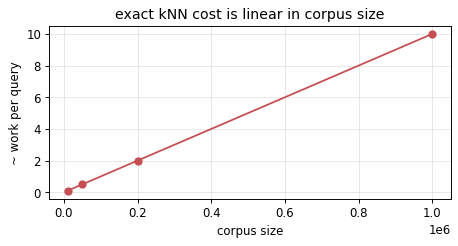

In [5]:
print("exact-scan latency grows with corpus size:")
for n in [10_000, 50_000, 200_000]:
    Xn = rng.normal(0, 1, (n, 64)).astype(np.float32); qn = rng.normal(0, 1, 64).astype(np.float32)
    t = time.perf_counter()
    for _ in range(20): np.argsort(-(Xn @ qn))[:10]
    dt = (time.perf_counter() - t) / 20
    print(f"  {n:>7,} vectors: {dt*1000:6.1f} ms/query")
print("\n-> at MILLIONS of vectors this blows the latency budget. ANN scans a FRACTION instead.")
plt.figure(figsize=(5.5,3))
ns = [10_000, 50_000, 200_000, 1_000_000]
plt.plot(ns, [n/1e5 for n in ns], "o-", color=RED)
plt.xlabel("corpus size"); plt.ylabel("~ work per query"); plt.title("exact kNN cost is linear in corpus size"); plt.show()

## Step 3 · How we grade an index — recall@k (on a tiny example)

**recall@k** = of the true top-k, how many did the approximate index return?
$$\text{recall@}k=\frac{|\text{approx top-}k \cap \text{exact top-}k|}{k}$$
Let's compute it by hand on 6 items so the formula is concrete, then we'll use it everywhere.

In [7]:
exact_ids  = [9, 3, 7, 2, 5, 1]        # the TRUE nearest neighbors, best first
approx_ids = [9, 7, 2, 8, 4, 0]        # what an approximate index returned
for k in [1, 3, 5]:
    overlap = set(approx_ids[:k]) & set(exact_ids[:k])
    print(f"  recall@{k}: exact top-{k}={exact_ids[:k]}  approx top-{k}={approx_ids[:k]}  "
          f"-> overlap {sorted(overlap)} -> {len(overlap)}/{k} = {len(overlap)/k:.2f}")
print("\nrecall@k is just 'what fraction of the true top-k did we recover?' -- higher is better.")

  recall@1: exact top-1=[9]  approx top-1=[9]  -> overlap [9] -> 1/1 = 1.00
  recall@3: exact top-3=[9, 3, 7]  approx top-3=[9, 7, 2]  -> overlap [7, 9] -> 2/3 = 0.67
  recall@5: exact top-5=[9, 3, 7, 2, 5]  approx top-5=[9, 7, 2, 8, 4]  -> overlap [2, 7, 9] -> 3/5 = 0.60

recall@k is just 'what fraction of the true top-k did we recover?' -- higher is better.


---
# Part B · IVF — partition & probe (the partition family)

## Step 4 · IVF step 1 — **partition** the corpus into cells

**Inverted File** indexing clusters all vectors into `nlist` **cells** (via k-means). Each
vector belongs to the nearest **centroid**. We do it in **2D first** so you can literally see
the cells, then apply the idea to the real 32-dim corpus.

every vector is now assigned to its nearest centroid -> 8 buckets ('inverted lists').


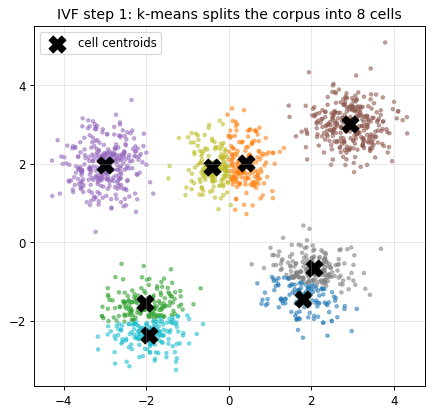

In [10]:
# a small 2D corpus so we can DRAW the cells
X2 = np.vstack([rng.normal(c, 0.5, (300, 2)) for c in [(-2,-2),(0,2),(2,-1),(3,3),(-3,2)]]).astype(np.float32)
km2 = KMeans(8, n_init=3, random_state=0).fit(X2)
cents2 = km2.cluster_centers_
plt.figure(figsize=(5.2,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.5)
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=200, color="k", label="cell centroids")
plt.legend(); plt.title("IVF step 1: k-means splits the corpus into 8 cells"); plt.show()
print("every vector is now assigned to its nearest centroid -> 8 buckets ('inverted lists').")

## Step 5 · IVF step 2 — **probe** only the nearest cells

At query time you **don't** scan every cell. You find the query's nearest **`nprobe`**
centroids and scan **only those cells**. Bigger `nprobe` = scan more of the corpus = higher
recall, higher latency. Watch how much gets scanned as `nprobe` grows.

  nprobe=1: probe cells [1] -> scan 161/1500 vectors
  nprobe=2: probe cells [1, 6] -> scan 302/1500 vectors
  nprobe=3: probe cells [1, 6, 4] -> scan 602/1500 vectors


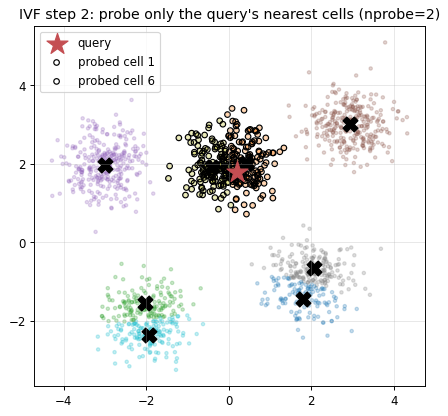

In [12]:
q2 = np.array([0.2, 1.8], dtype=np.float32)                       # a query in the 2D space
plt.figure(figsize=(5.2,5))
plt.scatter(X2[:,0], X2[:,1], c=km2.labels_, cmap="tab10", s=8, alpha=.25)
plt.scatter(cents2[:,0], cents2[:,1], marker="X", s=160, color="k")
plt.scatter(*q2, marker="*", s=350, color=RED, label="query", zorder=5)
near2 = np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:2]        # nprobe=2
for c in near2:
    pts = X2[km2.labels_ == c]
    plt.scatter(pts[:,0], pts[:,1], s=22, edgecolor="k", facecolor="none", label=f"probed cell {c}")
plt.legend(); plt.title("IVF step 2: probe only the query's nearest cells (nprobe=2)"); plt.show()

for nprobe in [1, 2, 3]:
    near = np.argsort(np.linalg.norm(cents2 - q2, axis=1))[:nprobe]
    scanned = sum((km2.labels_ == c).sum() for c in near)
    print(f"  nprobe={nprobe}: probe cells {list(near)} -> scan {scanned}/{len(X2)} vectors")

## Step 6 · IVF on the real corpus — the `nprobe` recall knob

Now the same two steps on the real 32-dim corpus. Sweep `nprobe` and measure **recall@20 vs %
of the corpus scanned** — the fundamental IVF tradeoff.

IVF on 6000 vectors in 64 cells

 nprobe  recall@20  % scanned
      1       0.64       1.7%
      2       0.94       3.2%
      4       1.00       6.1%
      8       1.00      12.2%
     16       1.00      24.3%
     32       1.00      49.0%


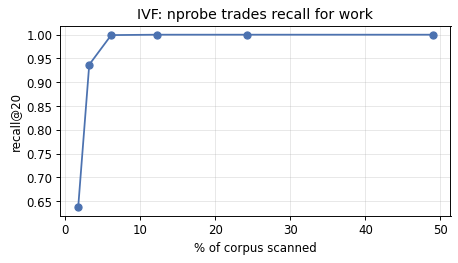

In [14]:
nlist = 64
km = KMeans(nlist, n_init=3, random_state=0).fit(X)
cents = km.cluster_centers_
members = [np.where(km.labels_ == c)[0] for c in range(nlist)]     # the inverted lists

def ivf(q, k=20, nprobe=8):
    near = np.argsort(-(cents @ q))[:nprobe]
    cand = np.concatenate([members[c] for c in near])
    if len(cand) < k: return set(cand)
    return set(cand[np.argsort(-(X[cand] @ q))[:k]])

print(f"IVF on {N} vectors in {nlist} cells\n")
print(f"{'nprobe':>7}{'recall@20':>11}{'% scanned':>11}")
ivf_rows = []
for nprobe in [1, 2, 4, 8, 16, 32]:
    rec = recall_of(lambda q, k: ivf(q, k, nprobe))
    scanned = np.mean([sum(len(members[c]) for c in np.argsort(-(cents@q))[:nprobe]) for q in Q]) / N
    ivf_rows.append((nprobe, rec, scanned*100)); print(f"{nprobe:>7}{rec:>11.2f}{scanned*100:>10.1f}%")
plt.figure(figsize=(5.5,3.2))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE)
plt.xlabel("% of corpus scanned"); plt.ylabel("recall@20"); plt.title("IVF: nprobe trades recall for work"); plt.show()

---
# Part C · PQ — compress the vectors (the quantization family)

## Step 7 · PQ step 1 — split each vector into subvectors

**Product Quantization** shrinks **memory**. First idea: chop each vector into `m` equal
**subvectors**. We'll compress the corpus down to a few **bytes per vector**. Start by seeing
the split.

In [17]:
m = 8; sub = DIM // m                              # 32 dims -> 8 subvectors of 4 dims each
print(f"each vector has {DIM} dims = {DIM*4} bytes (float32)")
print(f"split into m={m} subvectors of {sub} dims each:")
print("  vector 0 subvectors:")
for s in range(m):
    print(f"    subvector {s}: {X[0, s*sub:(s+1)*sub].round(2)}")

each vector has 32 dims = 128 bytes (float32)
split into m=8 subvectors of 4 dims each:
  vector 0 subvectors:
    subvector 0: [ 0.34 -0.39  1.44 -0.01]
    subvector 1: [ 0.12 -0.09 -1.78  0.65]
    subvector 2: [ 0.96  0.94 -1.21  0.53]
    subvector 3: [ 1.64  2.76  0.26 -0.04]
    subvector 4: [-1.54 -0.17 -1.06  0.57]
    subvector 5: [-0.91 -0.3   0.6  -0.07]
    subvector 6: [ 0.54 -0.38  0.5  -1.31]
    subvector 7: [ 0.5  -1.37 -0.   -0.42]


## Step 8 · PQ step 2 — learn a **codebook** per subvector position

For each subvector *position*, run k-means over the whole corpus to get `ksub` **centroids** (a
**codebook**). Then any subvector can be replaced by the **id** of its nearest centroid — one
small integer instead of `sub` floats.

In [19]:
ksub = 256                                         # 256 centroids -> fits in 1 byte (uint8)
codebooks, codes = [], np.zeros((N, m), dtype=np.uint8)
for s in range(m):
    part = X[:, s*sub:(s+1)*sub]
    kms = KMeans(ksub, n_init=2, random_state=0).fit(part)
    codebooks.append(kms.cluster_centers_.astype(np.float32))
    codes[:, s] = kms.labels_                        # <-- each subvector -> a centroid id
    if s < 3: print(f"  subvector position {s}: codebook shape {kms.cluster_centers_.shape}")
print(f"  ... ({m} codebooks total, each {ksub} centroids x {sub} dims)")
print(f"\nvector 0 is now the code {codes[0]}  ({m} bytes instead of {DIM*4})")

  subvector position 0: codebook shape (256, 4)
  subvector position 1: codebook shape (256, 4)
  subvector position 2: codebook shape (256, 4)
  ... (8 codebooks total, each 256 centroids x 4 dims)

vector 0 is now the code [183  47 242 114  98 207 241  38]  (8 bytes instead of 128)


## Step 9 · PQ step 3 — the memory win, and its cost (reconstruction error)

Now each vector is just `m` bytes. That's the memory win. The **cost** is **quantization
error**: reconstructing a vector from its codebook centroids is only approximate, so scores are
slightly off (which lowers recall). We measure both.

memory: 768 KB  ->  48 KB   (16x smaller)
quantization error: mean ||x - x_hat|| = 1.249  (the price of compression)

recall@20:  full-precision 1.00  ->  PQ-compressed 0.59


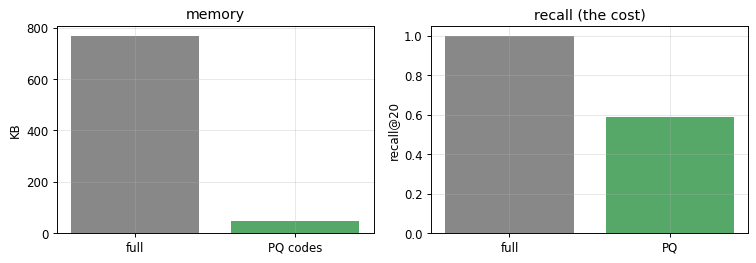

In [21]:
Xpq = np.concatenate([codebooks[s][codes[:, s]] for s in range(m)], axis=1)  # reconstruction
full_bytes, code_bytes = X.nbytes, codes.nbytes
recon_err = np.linalg.norm(X - Xpq, axis=1).mean()
print(f"memory: {full_bytes/1e3:.0f} KB  ->  {code_bytes/1e3:.0f} KB   ({full_bytes/code_bytes:.0f}x smaller)")
print(f"quantization error: mean ||x - x_hat|| = {recon_err:.3f}  (the price of compression)\n")
rec_pq   = recall_of(lambda q, k: set(np.argsort(-(Xpq @ q))[:k]))
rec_full = recall_of(lambda q, k: exact_topk(q, k))
print(f"recall@20:  full-precision {rec_full:.2f}  ->  PQ-compressed {rec_pq:.2f}")
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(["full","PQ codes"], [full_bytes/1e3, code_bytes/1e3], color=[GRAY, GREEN]); ax[0].set_ylabel("KB"); ax[0].set_title("memory")
ax[1].bar(["full","PQ"], [rec_full, rec_pq], color=[GRAY, GREEN]); ax[1].set_ylabel("recall@20"); ax[1].set_title("recall (the cost)")
plt.show()

---
# Part D · IVF-PQ — partition + compression + rerank

## Step 10 · Combine them (the real workhorse index)

**IVF-PQ** = probe a few cells (IVF) **and** store compressed codes (PQ) — tiny memory *and*
little scanning. The quantization error is fixed with a small **exact rerank**: score the
candidates cheaply with the compressed vectors, then re-score just the top few with the real
vectors. You get IVF-level recall at PQ-level memory.

In [24]:
def ivf_pq(q, k=20, nprobe=8, rerank=200):
    near = np.argsort(-(cents @ q))[:nprobe]
    cand = np.concatenate([members[c] for c in near])
    if len(cand) < k: return set(cand)
    top = cand[np.argsort(-(Xpq[cand] @ q))[:rerank]]      # 1. cheap: score with COMPRESSED vectors
    return set(top[np.argsort(-(X[top] @ q))[:k]])          # 2. exact rerank the top `rerank`

r_ivf   = recall_of(lambda q, k: ivf(q, k, nprobe=8))
r_ivfpq = recall_of(lambda q, k: ivf_pq(q, k, nprobe=8))
print(f"recall@20 @ nprobe=8:")
print(f"  IVF   (full vectors)         : {r_ivf:.2f}   memory {X.nbytes/1e3:.0f} KB")
print(f"  IVF-PQ (compressed + rerank) : {r_ivfpq:.2f}   memory {codes.nbytes/1e3:.0f} KB  ({X.nbytes/codes.nbytes:.0f}x less)")
print("\n-> the exact rerank recovers the recall PQ lost, at a fraction of the memory.")

recall@20 @ nprobe=8:
  IVF   (full vectors)         : 1.00   memory 768 KB
  IVF-PQ (compressed + rerank) : 1.00   memory 48 KB  (16x less)

-> the exact rerank recovers the recall PQ lost, at a fraction of the memory.


---
# Part E · HNSW — walk a graph (the graph family)

## Step 11 · HNSW step 1 — build a neighbor graph (+ long-range links)

**Hierarchical Navigable Small World** connects each vector to its nearest neighbors, plus a
few **long-range links** (HNSW's upper-layer shortcuts) so search can jump across the space. We
build the graph now; the next step *walks* it.

In [27]:
knn = NearestNeighbors(n_neighbors=16).fit(X); _, nn_graph = knn.kneighbors(X)
long_range = rng.integers(0, N, (N, 4))                        # a few random shortcuts per node
graph = np.concatenate([nn_graph, long_range], axis=1)
print(f"graph: {N} nodes, each with {nn_graph.shape[1]} near neighbors + {long_range.shape[1]} long-range links")
print("near neighbors keep search accurate; long-range links let it cross the space fast.")
print("node 0 links to:", graph[0][:8], "...")

graph: 6000 nodes, each with 16 near neighbors + 4 long-range links
near neighbors keep search accurate; long-range links let it cross the space fast.
node 0 links to: [   0   25 4221 5813 4042 3984 3387 3683] ...


## Step 12 · HNSW step 2 — **greedy walk** (traced hop by hop)

Search starts at some entry node and **repeatedly hops to whichever neighbor is closer to the
query**, until no neighbor improves. Watch the path: each hop increases similarity to the query
— the walk *climbs toward* the answer.

greedy walk visited 5 nodes before settling:
  path : [5165, 1011, 5807, 2109, 2946] 
  sims : [-17.9, 3.3, 47.7, 51.6, 54.6]   <- similarity climbs each hop


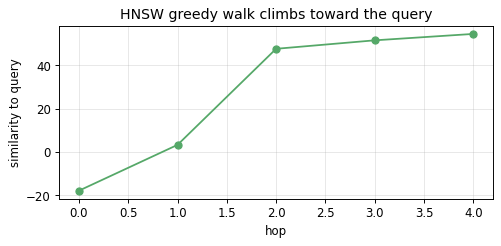

In [29]:
qv = X[rng.integers(0, N)] + rng.normal(0, 0.2, DIM)          # a query near some item
cur = int(np.argmin(X @ qv)); path = [cur]                    # start FAR (worst node) so the climb is visible
for _ in range(50):
    neigh = graph[cur]
    best = int(neigh[np.argmax(X[neigh] @ qv)])
    if X[best] @ qv <= X[cur] @ qv: break                     # no neighbor is closer -> stop
    cur = best; path.append(cur)
sims = [float(X[p] @ qv) for p in path]
print(f"greedy walk visited {len(path)} nodes before settling:")
print("  path :", path[:10], "..." if len(path) > 10 else "")
print("  sims :", [round(s,1) for s in sims[:10]], "  <- similarity climbs each hop")
plt.figure(figsize=(6,3)); plt.plot(sims, "o-", color=GREEN)
plt.xlabel("hop"); plt.ylabel("similarity to query"); plt.title("HNSW greedy walk climbs toward the query"); plt.show()

## Step 13 · HNSW step 3 — the `efSearch` knob

A single greedy path can get stuck, so real HNSW keeps a **candidate set of size `efSearch`**
(a small beam) and explores the best ones. Bigger `efSearch` = explore more = higher recall,
more nodes visited (latency). Sweep it.

 efSearch  recall@20  nodes visited  (of 6000)
       10       0.43            212
       20       0.71            294
       40       0.84            399
       80       0.91            576
      160       0.94            872


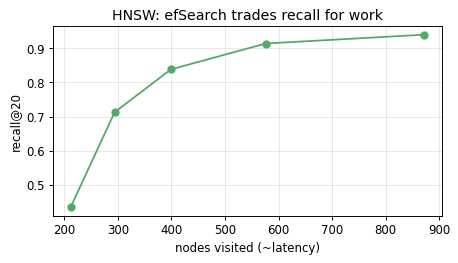

In [31]:
def hnsw(q, k=20, efSearch=40):
    dist = lambda i: -float(X[i] @ q)                          # smaller = closer
    entry = int(rng.integers(0, N)); d0 = dist(entry)
    cand = [(d0, entry)]; res = [(-d0, entry)]; seen = {entry}; visited = 1
    while cand:
        cd, c = heapq.heappop(cand)
        if cd > -res[0][0]: break                              # closest candidate worse than worst kept
        for e in graph[c]:
            if e in seen: continue
            seen.add(e); visited += 1; de = dist(e)
            if de < -res[0][0] or len(res) < efSearch:
                heapq.heappush(cand, (de, e)); heapq.heappush(res, (-de, e))
                if len(res) > efSearch: heapq.heappop(res)
    return set(e for _, e in heapq.nlargest(k, res)), visited

print(f"{'efSearch':>9}{'recall@20':>11}{'nodes visited':>15}  (of {N})")
hnsw_rows = []
for ef in [10, 20, 40, 80, 160]:
    recs = [len(exact_topk(q,20) & hnsw(q,20,ef)[0])/20 for q in Q]
    vis  = [hnsw(q,20,ef)[1] for q in Q]
    hnsw_rows.append((ef, np.mean(recs), np.mean(vis)))
    print(f"{ef:>9}{np.mean(recs):>11.2f}{np.mean(vis):>15.0f}")
plt.figure(figsize=(5.5,3.2))
plt.plot([r[2] for r in hnsw_rows], [r[1] for r in hnsw_rows], "o-", color=GREEN)
plt.xlabel("nodes visited (~latency)"); plt.ylabel("recall@20"); plt.title("HNSW: efSearch trades recall for work"); plt.show()

---
# Part F · ScaNN idea — score cheap, rerank exact

## Step 14 · The partition→quantize→rerank pattern

**ScaNN**-style systems share one pattern you can build in a few lines: **score everything with
a cheap approximation, then pay the full cost only on a small candidate set** (a rerank). Its
special sauce is *anisotropic* quantization (spend accuracy where score errors hurt MIPS most),
but the core idea is the cheap-score-then-rerank funnel.

In [34]:
Xcoarse = np.round(X * 4) / 4                        # a cheap, low-precision approximation
def scann_like(q, k=20, pool=200):
    coarse_top = np.argsort(-(Xcoarse @ q))[:pool]   # 1. CHEAP: score all with coarse vectors
    return set(coarse_top[np.argsort(-(X[coarse_top] @ q))[:k]])   # 2. EXACT rerank the top `pool`
r_scann = recall_of(lambda q, k: scann_like(q, k))
print(f"coarse-score all -> exact-rerank top-200:  recall@20 = {r_scann:.2f}")
print("you scored millions cheaply, but paid full price on only 200 candidates -> fast AND accurate.")

coarse-score all -> exact-rerank top-200:  recall@20 = 1.00
you scored millions cheaply, but paid full price on only 200 candidates -> fast AND accurate.


---
# Part G · Tuning: families, frontier, decision, hybrid

## Step 15 · Graph vs quantization — how each family saves work

Three ways to avoid scoring everything:

In [37]:
fams = pd.DataFrame({
    "family": ["IVF (partition)", "PQ / IVF-PQ (quantization)", "HNSW (graph)", "ScaNN (quant+rerank)"],
    "how it saves work": ["scan only a few cells", "store tiny compressed codes",
                          "walk a neighbor graph", "cheap score then rerank"],
    "main knob": ["nprobe", "code size / rerank", "efSearch", "leaves / reorder"],
    "watch out": ["misses unprobed cells", "quantization lowers recall",
                  "memory-heavy graph", "implementation-specific"],
})
print(fams.to_string(index=False))

                    family           how it saves work          main knob                  watch out
           IVF (partition)       scan only a few cells             nprobe      misses unprobed cells
PQ / IVF-PQ (quantization) store tiny compressed codes code size / rerank quantization lowers recall
              HNSW (graph)       walk a neighbor graph           efSearch         memory-heavy graph
      ScaNN (quant+rerank)     cheap score then rerank   leaves / reorder    implementation-specific


## Step 16 · The recall–latency frontier → pick an operating point

Don't ask "which index is best?" Ask "which setting is the **cheapest that meets the product's
recall bar and latency budget**?" Plot recall vs work; the good settings sit on the
**frontier** (nothing beats them on both axes). Pick the cheapest point above the bar.

cheapest IVF setting meeting recall>=0.9: nprobe=2  (0.94 recall, 3.2% scanned)


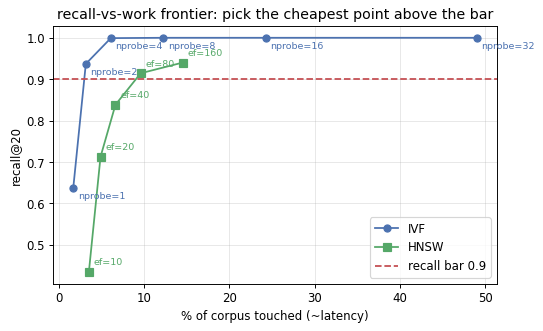

In [39]:
bar = 0.90
plt.figure(figsize=(6.5,4))
plt.plot([r[2] for r in ivf_rows], [r[1] for r in ivf_rows], "o-", color=BLUE, label="IVF")
for np_, rc, sc in ivf_rows: plt.annotate(f"nprobe={np_}", (sc, rc), textcoords="offset points", xytext=(4,-9), fontsize=8, color=BLUE)
plt.plot([r[2]/N*100 for r in hnsw_rows], [r[1] for r in hnsw_rows], "s-", color=GREEN, label="HNSW")
for ef, rc, vi in hnsw_rows: plt.annotate(f"ef={ef}", (vi/N*100, rc), textcoords="offset points", xytext=(4,6), fontsize=8, color=GREEN)
plt.axhline(bar, color=RED, ls="--", label=f"recall bar {bar}")
plt.xlabel("% of corpus touched (~latency)"); plt.ylabel("recall@20"); plt.legend()
plt.title("recall-vs-work frontier: pick the cheapest point above the bar"); plt.show()
ivf_ok = [r for r in ivf_rows if r[1] >= bar]
if ivf_ok:
    best = min(ivf_ok, key=lambda r: r[2])
    print(f"cheapest IVF setting meeting recall>={bar}: nprobe={best[0]}  ({best[1]:.2f} recall, {best[2]:.1f}% scanned)")

## Step 17 · The decision — HNSW vs IVF-PQ

They win in different regimes. The rule of thumb:

| Need / constraint | Prefer |
|---|---|
| Highest recall at moderate scale, **memory available** | **HNSW** (raise `efSearch`) |
| **Tight memory** budget | **IVF-PQ** (PQ compression) |
| **Very large, static** corpus | **IVF-PQ** (or ScaNN) |
| **Frequent updates / freshness** | **HNSW** often easier |
| Rare exact names / tokens / filters | add a **hybrid lexical** layer |

Our own numbers echo this: HNSW hit high recall but stores full vectors (memory-heavy); IVF-PQ
matched recall at **~8× less memory** via compression + rerank.

In [41]:
print("from THIS notebook's runs:")
print(f"  HNSW efSearch=160 : recall {hnsw_rows[-1][1]:.2f}, memory {X.nbytes/1e3:.0f} KB (full vectors)")
print(f"  IVF-PQ nprobe=8    : recall {recall_of(lambda q,k: ivf_pq(q,k,nprobe=8)):.2f}, memory {codes.nbytes/1e3:.0f} KB ({X.nbytes/codes.nbytes:.0f}x less)")
print("\ndecision: memory-bound -> IVF-PQ ; recall-bound with memory to spare -> HNSW.")

from THIS notebook's runs:
  HNSW efSearch=160 : recall 0.94, memory 768 KB (full vectors)
  IVF-PQ nprobe=8    : recall 1.00, memory 48 KB (16x less)

decision: memory-bound -> IVF-PQ ; recall-bound with memory to spare -> HNSW.


## Step 18 · Hybrid dense + lexical (Nano / Galene / HostedSearch)

Dense ANN is great for **semantic** matches — but it **loses exact names and rare tokens**. A
query for a specific creator can drown among semantically-similar ones. **Lexical / term search
(BM25)** nails exact tokens. **Hybrid** runs both and fuses:
`score = α·dense + (1−α)·lexical`. Use it whenever exact names, SKUs, or keyword filters matter.

on 150 exact-name queries:
  dense-only recall@20 : 0.77  (target lost among similar items)
  hybrid     recall@20 : 1.00  (lexical exact-token match recovers it)


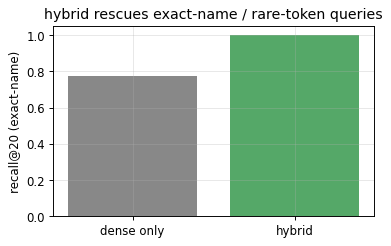

In [43]:
targets = rng.choice(N, 150, replace=False)          # 150 'find this EXACT item' queries
def dense_topk(qv, k=20): return list(np.argsort(-(X @ qv))[:k])
def lexical_match(item_id): return [item_id]          # BM25 on a rare exact token -> that item

dense_hit = hybrid_hit = 0
for t in targets:
    qv = X[t] + rng.normal(0, 0.3, DIM)               # query lands in a CROWDED topic
    dtop = dense_topk(qv, 20)
    dense_hit  += int(t in dtop)
    hybrid_hit += int(t in set(dtop) | set(lexical_match(t)))
print("on 150 exact-name queries:")
print(f"  dense-only recall@20 : {dense_hit/len(targets):.2f}  (target lost among similar items)")
print(f"  hybrid     recall@20 : {hybrid_hit/len(targets):.2f}  (lexical exact-token match recovers it)")
plt.figure(figsize=(4.6,3)); plt.bar(["dense only","hybrid"], [dense_hit/len(targets), hybrid_hit/len(targets)], color=[GRAY, GREEN])
plt.ylabel("recall@20 (exact-name)"); plt.title("hybrid rescues exact-name / rare-token queries"); plt.show()

---
## Recap — the M13 toolkit

**Why ANN.** Exact kNN scores every vector (linear in corpus size). ANN searches a **fraction**
and accepts some **recall loss**, graded by **recall@k** against an exact baseline.

**The three families (how each skips work):**
- **IVF** — **partition** into cells, **probe** the nearest `nprobe` (scans a fraction).
- **PQ / IVF-PQ** — **compress** vectors into tiny codes (huge memory win); a small **exact
  rerank** recovers the recall PQ loses.
- **HNSW** — **greedy-walk** a neighbor graph with beam `efSearch` (high recall, memory-heavy).
- **ScaNN** — the **cheap-score-then-rerank** funnel with anisotropic quantization.

**Tuning.** Sweep the knob (`nprobe` / `efSearch` / rerank), plot **recall vs latency & memory**,
and pick the **cheapest point on the frontier** that meets the product bar.

**HNSW vs IVF-PQ.** Memory-bound or very large/static → **IVF-PQ**; recall-bound with memory to
spare → **HNSW**. Add **hybrid dense + lexical (BM25)** when exact names / rare tokens / filters
matter.

**Checklist:** measure an exact baseline → sweep knobs together → plot recall vs p50/p95 latency
& memory → validate **slices** (tail, cold-start, language) → check **freshness** (index rebuild
lag) → find the real bottleneck (index recall, candidate count, filters, or reranker).

**Where this connects:** M13 is the index behind M12's retrieval funnel; the vectors it searches
are M11's embeddings, trained as **contrastive encoders** — the subject of **M14**.